# NMR

## Calculating T2 for Light Mineral Oil

In [44]:
import mcphysics
import spinmob as s
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
%matplotlib inline

sns.set_theme(
    "paper",
    "ticks",
    font="Helvetica"
)

### Loading Data

In [46]:
datas = []

for i in range(9):
    data = s.data.load(f"t2/000{i} t2_0.txt")
    datas.append(data)

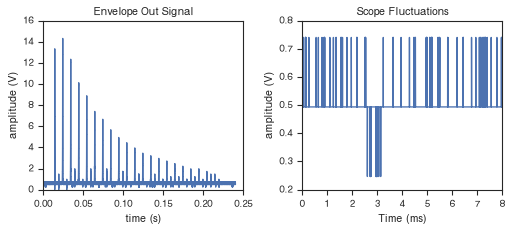

In [106]:
fig, ax = plt.subplots(1, 2, figsize=(6.5, 3))
data = datas[0]

ax[0].plot(data[0], data[1])
ax[0].set_xlabel("time (s)")
ax[0].set_ylabel("amplitude (V)")
ax[0].set_title("Envelope Out Signal")

ax[1].plot(data[0][:100000] * 1e3, data[1][:100000])
ax[1].set_xlabel("Time (ms)")
ax[1].set_ylabel("amplitude (V)")
ax[1].set_title("Scope Fluctuations")

fig.tight_layout()
plt.savefig("figure_1.png", dpi=600,)
plt.show()

In [93]:
deltas = np.diff(datas[0][1])
print(np.min(deltas), np.max(deltas))

-0.25 0.25


### Data Analysis

In [48]:
# Find peaks
peak_points = []

for data in datas:
    peaks = sp.signal.find_peaks(
        data[1],
        height = 1,
        distance = 3e6 / 30
    )
    times = data[0][peaks[0][1:]]
    times -= times[0]
    amplitudes = peaks[1]["peak_heights"][1:]

    ans = np.vstack([times[:19], amplitudes[:19]])
    peak_points.append(ans)

In [98]:
# Estimate uncertainty
all_point_vals = np.vstack([points[1] for points in peak_points])
means = np.mean(all_point_vals, axis=0)
times = peak_points[0][0]

sems = np.std(all_point_vals, axis=0, ddof=1) / np.sqrt(len(peak_points))
resolution_error = 0.25 / np.sqrt(12)
uncertainties = np.sqrt(sems**2 + resolution_error**2)

In [99]:
# Fit curve
model = lambda t, M_0, T_2, b: M_0 * np.exp(-t / T_2) + b

fit = sp.optimize.curve_fit(
    model,
    times,
    means,
    p0 = (14, 0.1, -0.5),
    bounds = ((0, 0, -2), (20, 0.2, 2)),
    sigma = uncertainties,
    absolute_sigma=True
)
print(fit[0])
perr = np.sqrt(np.diag(fit[1]))
print(perr)

[12.91935263  0.05604584  1.37704539]
[0.06222393 0.00078642 0.05455555]


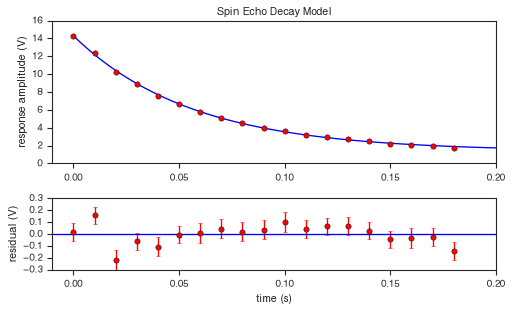

In [107]:
space = np.linspace(0, 0.2, 100)
vals = model(space, *fit[0])

fig, ax = plt.subplots(2, 1, figsize=(6.5, 4), height_ratios=(2, 1))

ax[0].plot(space, vals, color="blue")
ax[0].errorbar(times, means, yerr=uncertainties, fmt='o', color="red", capsize=2)
ax[0].set_xlim([-0.01, 0.2])
ax[0].set_ylabel("response amplitude (V)")
ax[0].set_title("Spin Echo Decay Model")

residuals = means - model(times, *fit[0])
ax[1].errorbar(times, residuals, yerr=uncertainties, fmt='o', color="red", capsize=2)
ax[1].axhline(0, color="blue")
ax[1].set_xlim([-0.01, 0.2])
ax[1].set_xlabel("time (s)")
ax[1].set_ylabel("residual (V)")

fig.tight_layout()
plt.savefig("figure_2.png", dpi=600)